In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
import os
import json
import pandas as pd

def collect_metrics_from(model_dir):
    """
    Given a directory like 'VGRU_finalrun' or 'VLSTM_finalrun',
    finds all 'shrink_train_*' subdirectories, loads their
    performance_metrics.json, and returns a sorted DataFrame.
    """
    if not os.path.isdir(model_dir):
        raise FileNotFoundError(f"Directory not found: {model_dir}")

    # 1) Discover & sort shrink_train directories inside model_dir
    shrink_dirs = sorted(
        [
            d for d in os.listdir(model_dir)
            if os.path.isdir(os.path.join(model_dir, d)) and d.startswith('shrink_train_')
        ],
        key=lambda x: int(x.split('_')[2])
    )

    # 2) Collect metrics into a list of dicts
    records = []
    for d in shrink_dirs:
        full_path = os.path.join(model_dir, d)
        metrics_path = os.path.join(full_path, 'performance_metrics.json')
        if not os.path.exists(metrics_path):
            print(f"Warning: no metrics in {full_path}, skipping")
            continue

        with open(metrics_path, 'r') as f:
            metrics = json.load(f)

        # parse out N_removed from the directory name
        N = int(d.split('_')[2])
        rec = {'N_removed': N}

        # flatten output_1 and output_2 metrics
        for output in ['output_1', 'output_2']:
            for m in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
                rec[f"{output}_{m}"] = metrics.get(output, {}).get(m, None)

        records.append(rec)

    # 3) Build and sort DataFrame
    df = pd.DataFrame(records)
    df = df.sort_values('N_removed').reset_index(drop=True)
    # Add a column for N_sensors (reverse of N_removed)
    df['N_sensors'] = df['N_removed'].iloc[::-1].values
    return df

# Specify the two model directories
model_dirs = ['VGRU_finalrun', 'VLSTM_finalrun']

# Collect into a dict of DataFrames
dfs = {}
for mdl in model_dirs:
    try:
        dfs[mdl] = collect_metrics_from(mdl)
    except FileNotFoundError as e:
        print(e)
        dfs[mdl] = pd.DataFrame()  # empty DataFrame if directory not found

# Now dfs['VGRU_finalrun'] and dfs['VLSTM_finalrun'] are your two DataFrames:
df_vgru  = dfs['VGRU_finalrun']
df_vlstm = dfs['VLSTM_finalrun']

# (Optional) Display them
print("VGRU metrics:")
print(df_vgru.head(), "\n")
print("VLSTM metrics:")
print(df_vlstm.head())

VGRU metrics:
   N_removed  output_1_r2  output_1_mae  output_1_mape  output_1_rmse  \
0          1     0.995113      9.697199       3.458915      12.923441   
1          2     0.997788      7.143486       4.616601       8.695124   
2          3     0.998438      4.804155       2.079573       7.306578   
3          4     0.994139     11.833476       6.853224      14.153383   
4          5     0.996699      6.725829       3.267807      10.621661   

   output_1_rmspe  output_2_r2  output_2_mae  output_2_mape  output_2_rmse  \
0        4.976784     0.982524     17.202501      12.960374      19.972521   
1        7.401309     0.990158     10.828763      10.868604      14.988434   
2        4.407791     0.994230      9.172298      14.048286      11.476123   
3        9.850765     0.995524      6.218498       6.074585      10.108067   
4        6.732960     0.993518      9.758479      12.296189      12.163539   

   output_2_rmspe  N_sensors  
0       15.187000         61  
1       17.34453

C:\Users\Logan\AppData\Local\Temp\ipykernel_35692\1792048635.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


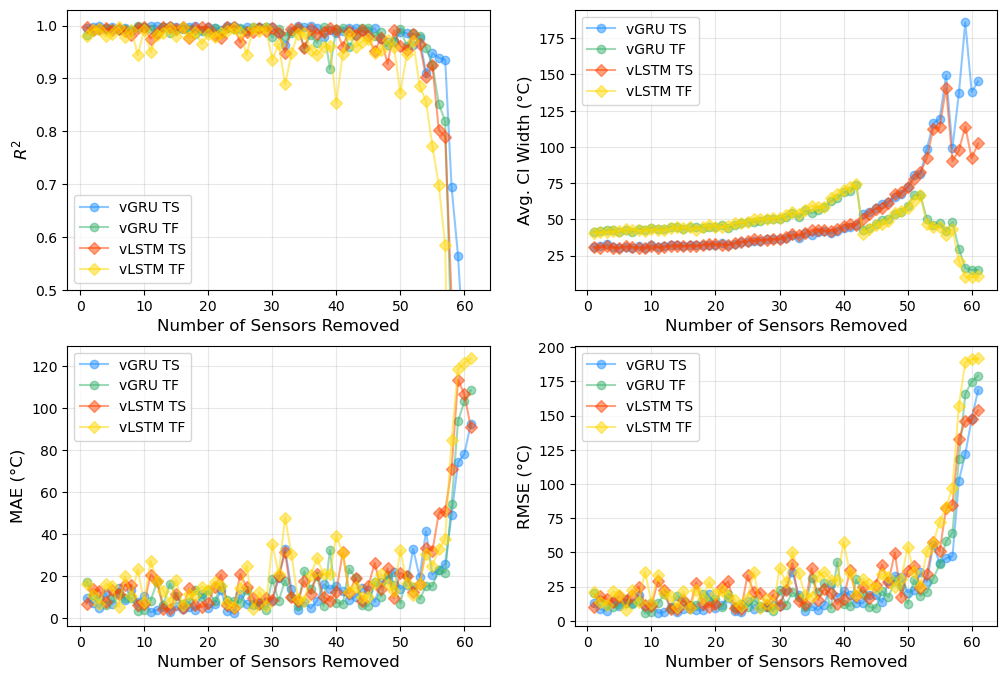

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# --- Helper to compute average CI width per output for each shrink_train dir ---
def compute_avg_ci_widths_per_output(model_dir):
    """
    For each 'shrink_train_{N}' under model_dir, load 'Ypred.npy' (shape (T, 2, 3)).
    Compute width = (upper_ci − lower_ci) separately for output 1 and output 2:
      widths_TS = Ypred[:, 0, 2] − Ypred[:, 0, 1]
      widths_TF = Ypred[:, 1, 2] − Ypred[:, 1, 1]
    Then average over all T to get two scalars per N. Returns:
      Ns (sorted list), avg_TS, avg_TF  (each a list aligned with Ns).
    """
    shrink_dirs = sorted(
        [
            d for d in os.listdir(model_dir)
            if os.path.isdir(os.path.join(model_dir, d)) and d.startswith('shrink_train_')
        ],
        key=lambda x: int(x.split('_')[2])
    )
    Ns = []
    avg_TS = []
    avg_TF = []
    for d in shrink_dirs:
        N = int(d.split('_')[2])
        pfile = os.path.join(model_dir, d, 'Ypred.npy')
        if not os.path.exists(pfile):
            print(f"Warning: Ypred.npy not found in {os.path.join(model_dir, d)}; skipping")
            continue

        Ypred = np.load(pfile)  # shape (T, 2, 3)
        # width for TS (output 1) and TF (output 2)
        width_TS = Ypred[:, 0, 2] - Ypred[:, 0, 1]  # shape (T,)
        width_TF = Ypred[:, 1, 2] - Ypred[:, 1, 1]  # shape (T,)
        avg_TS.append(width_TS.mean())
        avg_TF.append(width_TF.mean())
        Ns.append(N)

    return Ns, avg_TS, avg_TF

# --- Assume df_vgru and df_vlstm already exist as before ---

# 1) Compute average CI widths per output for both models
vgru_Ns,  vgru_avg_TS,  vgru_avg_TF  = compute_avg_ci_widths_per_output('VGRU_finalrun')
vlstm_Ns, vlstm_avg_TS, vlstm_avg_TF = compute_avg_ci_widths_per_output('VLSTM_finalrun')

# 2) Define column names and y-labels for each metric/output
metrics = {
    'R²':   {'col1': 'output_1_r2',  'col2': 'output_2_r2',  'ylabel': r'$R^2$'},
    'MAE':  {'col1': 'output_1_mae', 'col2': 'output_2_mae', 'ylabel': 'MAE (°C)'},
    'RMSE': {'col1': 'output_1_rmse','col2': 'output_2_rmse','ylabel': 'RMSE (°C)'}
}

# 3) Define a distinct color mapping for (model, output)
line_colors = {
    ('vGRU', 'TS'): 'dodgerblue',
    ('vGRU', 'TF'): 'mediumseagreen',
    ('vLSTM', 'TS'): 'orangered',
    ('vLSTM', 'TF'): 'gold'
}

# 4) Define markers by model
model_markers = {
    'vGRU':  'o',
    'vLSTM': 'D'
}

# 5) Create figure and 2×2 GridSpec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 1],
    hspace=0.2,
    wspace=0.2
)

# 6) Top-left: R² plot (in gs[0,0])
ax_r2 = fig.add_subplot(gs[0, 0])
for model_label, df in [('vGRU', df_vgru), ('vLSTM', df_vlstm)]:
    for output_idx, output_name in [(1, 'TS'), (2, 'TF')]:
        colname = metrics['R²'][f'col{output_idx}']
        ax_r2.plot(
            df['N_removed'],
            df[colname],
            color=line_colors[(model_label, output_name)],
            marker=model_markers[model_label],
            linestyle='-',
            alpha=0.5,
            label=f"{model_label} {output_name}"
        )

#ax_r2.set_title(r"$R^2$ vs. Number of Sensors Removed", fontsize=14)
ax_r2.set_xlabel("Number of Sensors Removed", fontsize=12)
ax_r2.set_ylabel(metrics['R²']['ylabel'], fontsize=12)
ax_r2.set_ylim(0.5, 1.03)
ax_r2.legend(loc='best', fontsize=10)
ax_r2.grid(alpha=0.3)

# 7) Top-right: Avg. CI width per output (in gs[0,1])
ax_ci = fig.add_subplot(gs[0, 1])
# vGRU TS & TF
ax_ci.plot(
    vgru_Ns,
    vgru_avg_TS,
    color=line_colors[('vGRU', 'TS')],
    marker=model_markers['vGRU'],
    linestyle='-',
    alpha=0.5,
    label='vGRU TS'
)
ax_ci.plot(
    vgru_Ns,
    vgru_avg_TF,
    color=line_colors[('vGRU', 'TF')],
    marker=model_markers['vGRU'],
    linestyle='-',
    alpha=0.5,
    label='vGRU TF'
)
# vLSTM TS & TF
ax_ci.plot(
    vlstm_Ns,
    vlstm_avg_TS,
    color=line_colors[('vLSTM', 'TS')],
    marker=model_markers['vLSTM'],
    linestyle='-',
    alpha=0.5,
    label='vLSTM TS'
)
ax_ci.plot(
    vlstm_Ns,
    vlstm_avg_TF,
    color=line_colors[('vLSTM', 'TF')],
    marker=model_markers['vLSTM'],
    linestyle='-',
    alpha=0.5,
    label='vLSTM TF'
)

#ax_ci.set_title("Avg. CI Width vs. Number of Sensors Removed", fontsize=14)
ax_ci.set_xlabel("Number of Sensors Removed", fontsize=12)
ax_ci.set_ylabel("Avg. CI Width (°C)", fontsize=12)
ax_ci.legend(loc='best', fontsize=10)
ax_ci.grid(alpha=0.3)

# 8) Bottom-left: MAE plot (in gs[1,0])
ax_mae = fig.add_subplot(gs[1, 0])
for model_label, df in [('vGRU', df_vgru), ('vLSTM', df_vlstm)]:
    for output_idx, output_name in [(1, 'TS'), (2, 'TF')]:
        colname = metrics['MAE'][f'col{output_idx}']
        ax_mae.plot(
            df['N_removed'],
            df[colname],
            color=line_colors[(model_label, output_name)],
            marker=model_markers[model_label],
            linestyle='-',
            alpha=0.5,
            label=f"{model_label} {output_name}"
        )

#ax_mae.set_title("MAE vs. Number of Sensors Removed", fontsize=14)
ax_mae.set_xlabel("Number of Sensors Removed", fontsize=12)
ax_mae.set_ylabel(metrics['MAE']['ylabel'], fontsize=12)
ax_mae.legend(loc='best', fontsize=10)
ax_mae.grid(alpha=0.3)

# 9) Bottom-right: RMSE plot (in gs[1,1])
ax_rmse = fig.add_subplot(gs[1, 1])
for model_label, df in [('vGRU', df_vgru), ('vLSTM', df_vlstm)]:
    for output_idx, output_name in [(1, 'TS'), (2, 'TF')]:
        colname = metrics['RMSE'][f'col{output_idx}']
        ax_rmse.plot(
            df['N_removed'],
            df[colname],
            color=line_colors[(model_label, output_name)],
            marker=model_markers[model_label],
            linestyle='-',
            alpha=0.5,
            label=f"{model_label} {output_name}"
        )

#ax_rmse.set_title("RMSE vs. Number of Sensors Removed", fontsize=14)
ax_rmse.set_xlabel("Number of Sensors Removed", fontsize=12)
ax_rmse.set_ylabel(metrics['RMSE']['ylabel'], fontsize=12)
ax_rmse.legend(loc='best', fontsize=10)
ax_rmse.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('HTTF_shrink_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# Load all runs
runs = []
for d in dirs:
    N = int(d.split('_')[2])
    tfile = os.path.join(d, 'Ytrue_rescaled.npy')
    pfile = os.path.join(d, 'Ypred_rescaled.npy')
    if os.path.exists(tfile) and os.path.exists(pfile):
        Ytrue = np.load(tfile)
        Ypred = np.load(pfile)
        runs.append((N, Ytrue, Ypred))

# Sample every 20th run (or choose your sampling interval)
sampled = runs[::5]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# Set fixed x-axis endpoint
x_end = 340070

# Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# Plot outputs 1 and 2 separately
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # true series: first run bold, others faded
        if i == 0:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=2, label='True')
        else:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=1, alpha=0.3)

        # predicted series: dashed, colored by N
        plt.plot(x_vals, Ypred[:, out_idx],
                 '--', color=cmap(i), alpha=1, label=f"Pred N={N} removed")

    plt.xlabel('Time Step')
    ylabel = 'TS' if out_idx == 0 else 'TF'
    plt.ylabel('Temperature (°C)')
    plt.title(f"True vs Predicted for {ylabel} (every 5th N, aligned end)")
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0, 1200)
    plt.legend(ncol=3)
    
    # vertical sensor boundaries
    for x_val in np.arange(5485, x_end, 5485):
        plt.vlines(x=x_val, ymin=-100, ymax=1500,
                   color='gray', linestyle='--',
                   linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    plt.show()


RuntimeError: No valid runs found to plot.

C:\Users\Logan\AppData\Local\Temp\ipykernel_8072\3132307583.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', len(sampled))


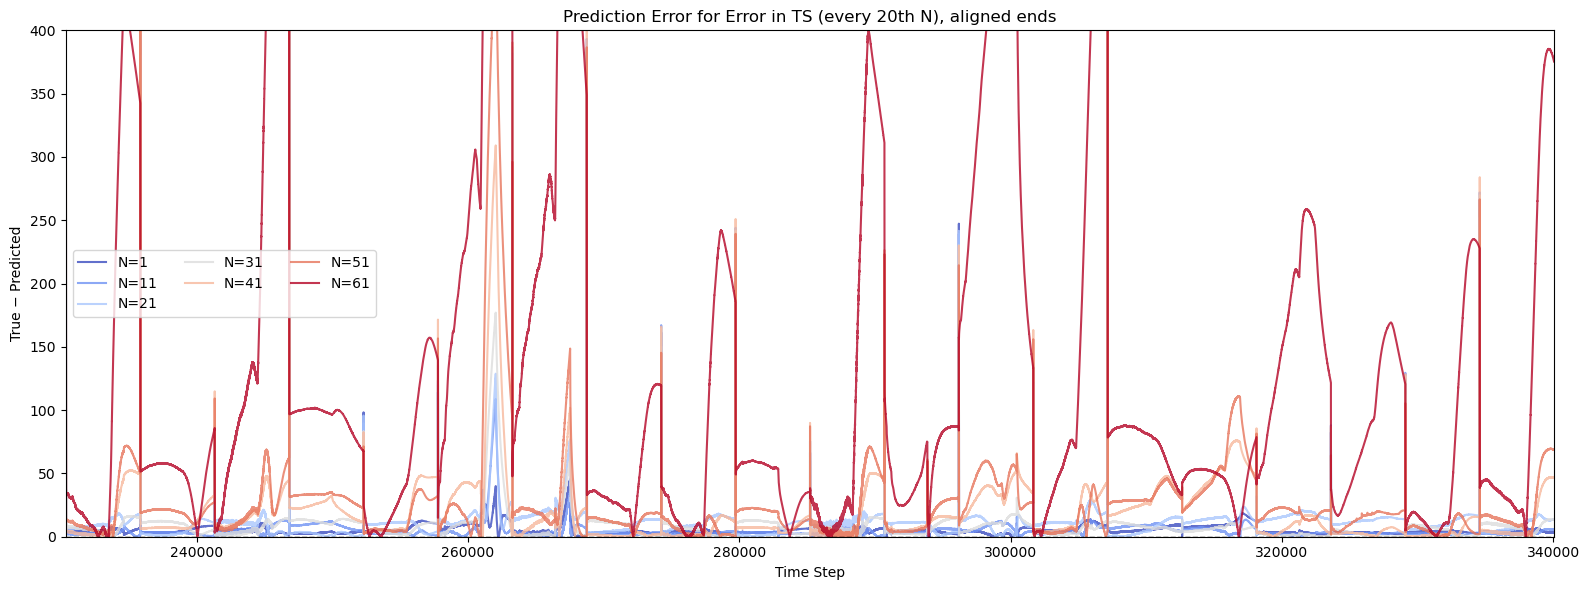

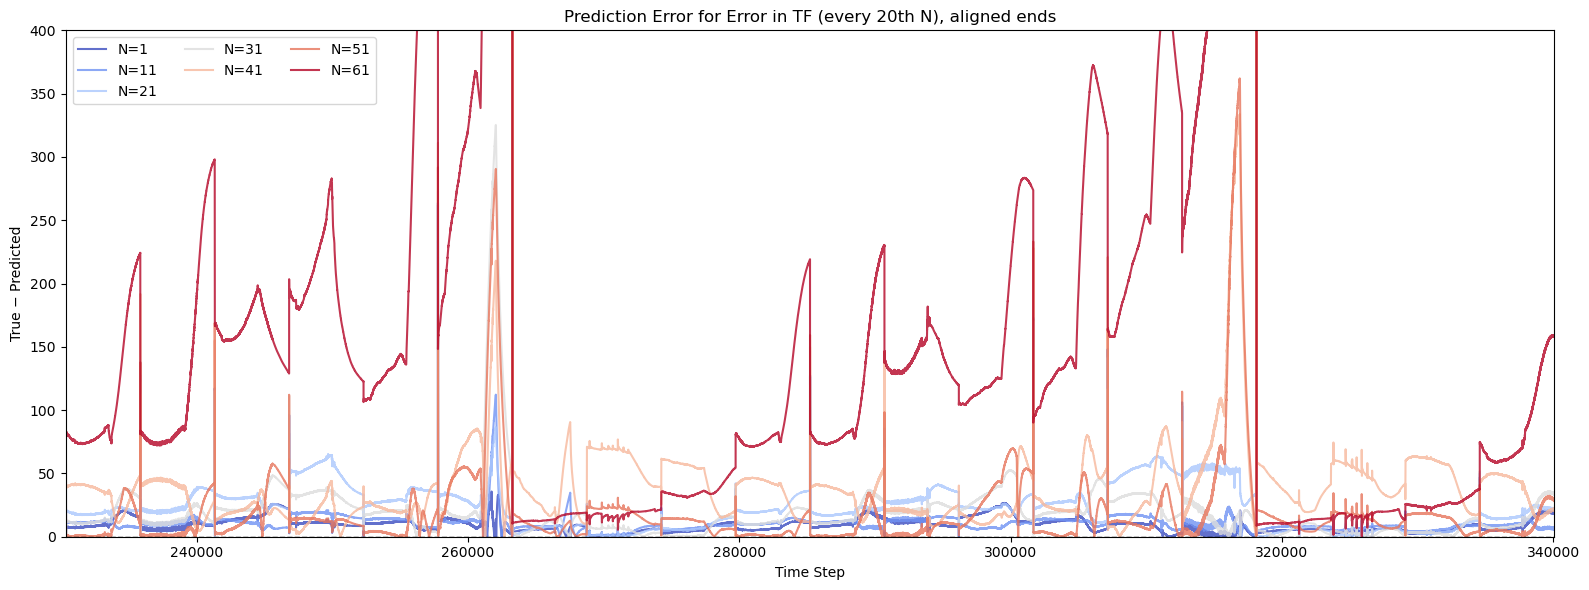

In [33]:
# # 1) Gather & sort your reallocate directories
# dirs = sorted(
#     [d for d in os.listdir('.') if os.path.isdir(d) and d.startswith('reallocate_')],
#     key=lambda x: int(x.split('_')[1])
# )

# # 2) Load all runs
# runs = []
# for d in dirs:
#     N = int(d.split('_')[1])
#     tfile = os.path.join(d, 'Ytrue_rescaled.npy')
#     pfile = os.path.join(d, 'Ypred_rescaled.npy')
#     if os.path.exists(tfile) and os.path.exists(pfile):
#         Ytrue = np.load(tfile)
#         Ypred = np.load(pfile)
#         runs.append((N, Ytrue, Ypred))

# 3) Sample every 20th run (or change the interval)
sampled = runs[::10]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# 4) Fixed x-axis endpoint
x_end = 340070

# 5) Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# 6) Plot error (true - pred) separately for each output
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # compute error: true minus predicted
        error = np.abs(Ytrue[:, out_idx] - Ypred[:, out_idx])

        # plot error curve
        plt.plot(x_vals, error,
                 color=cmap(i), alpha=0.8,
                 label=f"N={N}")

    # zero line
    plt.axhline(0, color='black', linewidth=1, linestyle='--')

    plt.xlabel('Time Step')
    ylabel = 'Error in TS' if out_idx == 0 else 'Error in TF'
    plt.ylabel('True − Predicted')
    plt.title(f'Prediction Error for {ylabel} (every 20th N), aligned ends')
    plt.legend(ncol=3)
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0,400)
    #plt.yscale('log')
    plt.tight_layout()
    plt.show()